# Unit Ball Ground-Truth Validation

This notebook validates numerical Dirichlet spectra on the unit ball
\[
\Omega(1,1,1)=\{x\in\mathbb{R}^3:\|x\|<1\}
\]
against the exact eigenvalues
\[
\lambda_{\ell,k}=j_{\ell+1/2,k}^2,
\]
with multiplicity \(2\ell+1\).

It is a **load-only** notebook: solver runs remain in Slurm jobs. It supports FEM--ARPACK and SSG ordered-spectrum validation, multiplicity-aware diagnostics, optional resolvent Block-Hankel landmark validation, and publication-ready exports.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import spherical_jn

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_ROOT = Path.home() / "data"
OUTPUTS_DIR = DATA_ROOT / "outputs"

ARNOLDI_DIR = OUTPUTS_DIR / "arnoldi_reference_sphere"
SSG_DIR     = OUTPUTS_DIR / "ssg_reference_sphere"
SLEPC_DIR   = OUTPUTS_DIR / "slepc_slicing_unitball"
HANKEL_DIR  = OUTPUTS_DIR / "hankel_full_spectrum_unitball"

ANALYSIS_DIR = OUTPUTS_DIR / "unit_ball_ground_truth_validation"
FIG_DIR = ANALYSIS_DIR / "figures"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_TARGET = 2000
print("Analysis:", ANALYSIS_DIR)

Analysis: /home/esul01/data/outputs/unit_ball_ground_truth_validation


## 1. Locate numerical output files

In [2]:
def first_match(directory: Path, patterns: list[str]):
    for pattern in patterns:
        matches = sorted(directory.glob(pattern))
        if matches:
            return matches[-1]
    return None

ARNOLDI_PATH = ARNOLDI_DIR / "ellipsoid_a1_b1_c1_P2_h0.06_arnoldi_highacc_N2000_eigs.txt"
SSG_PATH     = SSG_DIR / "ellipsoid_a1_b1_c1_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt"
SLEPC_PATH   = SLEPC_DIR / "unitball_slepc_slicing_eigs.txt"
HANKEL_PATH  = HANKEL_DIR / "full_spectrum_eigs_certified.txt"

for name, p in (("Arnoldi", ARNOLDI_PATH), ("SSG", SSG_PATH), ("SLEPc", SLEPC_PATH), ("Hankel", HANKEL_PATH)):
    print(f"{name:8s}", p)


Arnoldi  /home/esul01/data/outputs/arnoldi_reference_sphere/ellipsoid_a1_b1_c1_P2_h0.06_arnoldi_highacc_N2000_eigs.txt
SSG      /home/esul01/data/outputs/ssg_reference_sphere/ellipsoid_a1_b1_c1_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt
SLEPc    /home/esul01/data/outputs/slepc_slicing_unitball/unitball_slepc_slicing_eigs.txt
Hankel   /home/esul01/data/outputs/hankel_full_spectrum_unitball/full_spectrum_eigs_certified.txt


## 2. Generate the exact unit-ball spectrum

In [3]:
def spherical_bessel_roots(l: int, x_max: float, step: float = 0.025) -> np.ndarray:
    grid = np.arange(max(1e-8, 0.5 * step), x_max + step, step)
    vals = spherical_jn(l, grid)
    roots = []
    for i in range(len(grid) - 1):
        y0, y1 = vals[i], vals[i + 1]
        if not (np.isfinite(y0) and np.isfinite(y1)):
            continue
        if y0 == 0.0:
            root = grid[i]
        elif y0 * y1 < 0.0:
            root = brentq(lambda x: spherical_jn(l, x), grid[i], grid[i+1],
                          xtol=1e-14, rtol=1e-14, maxiter=100)
        else:
            continue
        if root > 1e-7 and (not roots or abs(root - roots[-1]) > 1e-9):
            roots.append(root)
    return np.asarray(roots)

def generate_exact_unit_ball_spectrum(n_target=2000, x_max=40.0, l_max=45):
    while True:
        levels = []
        for l in range(l_max + 1):
            roots = spherical_bessel_roots(l, x_max)
            for radial_index, root in enumerate(roots, start=1):
                levels.append({
                    "l": l,
                    "radial_index": radial_index,
                    "root": root,
                    "lambda_exact": root**2,
                    "multiplicity": 2*l + 1,
                })
        levels_df = pd.DataFrame(levels).sort_values("lambda_exact").reset_index(drop=True)

        rows = []
        for level_id, row in levels_df.iterrows():
            for m_slot in range(int(row["multiplicity"])):
                rows.append({
                    "level_id": level_id,
                    "l": int(row["l"]),
                    "radial_index": int(row["radial_index"]),
                    "multiplicity": int(row["multiplicity"]),
                    "m_slot": m_slot,
                    "root": float(row["root"]),
                    "lambda_exact": float(row["lambda_exact"]),
                })
        repeated_df = pd.DataFrame(rows).sort_values("lambda_exact").reset_index(drop=True)
        repeated_df["index"] = np.arange(1, len(repeated_df)+1)

        if len(repeated_df) >= n_target:
            repeated_df = repeated_df.iloc[:n_target].copy()
            cutoff = repeated_df["lambda_exact"].max()
            levels_df = levels_df[levels_df["lambda_exact"] <= cutoff + 1e-10].copy()
            return repeated_df, levels_df

        x_max *= 1.25
        l_max += 10

exact_df, exact_levels_df = generate_exact_unit_ball_spectrum(N_TARGET)
exact_df.to_csv(ANALYSIS_DIR / f"unit_ball_exact_N{N_TARGET}.csv", index=False)
exact_levels_df.to_csv(ANALYSIS_DIR / f"unit_ball_exact_levels_to_N{N_TARGET}.csv", index=False)

print("Repeated eigenvalues:", len(exact_df))
print("Distinct levels:", len(exact_levels_df))
print("lambda_1:", exact_df.iloc[0]["lambda_exact"])
print("pi^2:", np.pi**2)
print("lambda_2000:", exact_df.iloc[-1]["lambda_exact"])
display(exact_df.head(20))

Repeated eigenvalues: 2000
Distinct levels: 119
lambda_1: 9.869604401089353
pi^2: 9.869604401089358
lambda_2000: 1001.6976949414133


,level_id,l,radial_index,multiplicity,m_slot,root,lambda_exact,index
0,0,0,1,1,0,3.141593,9.869604,1
1,1,1,1,3,0,4.493409,20.190729,2
2,1,1,1,3,1,4.493409,20.190729,3
3,1,1,1,3,2,4.493409,20.190729,4
4,2,2,1,5,0,5.763459,33.217462,5
5,2,2,1,5,1,5.763459,33.217462,6
6,2,2,1,5,2,5.763459,33.217462,7
7,2,2,1,5,3,5.763459,33.217462,8
8,2,2,1,5,4,5.763459,33.217462,9
9,3,0,2,1,0,6.283185,39.478418,10


In [4]:
REFERENCE_DIR = DATA_ROOT / "reference"
GT_PATH = REFERENCE_DIR / "unit_ball_N20000.txt"

gt = np.sort(np.atleast_1d(np.loadtxt(GT_PATH)).astype(float))
gt = gt[np.isfinite(gt) & (gt > 0)][:N_TARGET]
print(f"ground truth: {len(gt)} levels, {gt[0]:.12f} .. {gt[-1]:.6f}")

# Gegenprobe: eigene Bessel-Wurzeln vs. Wolfram-Referenz
own = exact_df["lambda_exact"].to_numpy()[:len(gt)]
d = np.abs(own - gt) / gt
print(f"own vs. reference: median {np.median(d):.2e}, max {d.max():.2e}")

exact_df = exact_df.iloc[:len(gt)].copy()
exact_df["lambda_exact"] = gt          # Wolfram-Werte als Ground Truth verwenden

ground truth: 2000 levels, 9.869604401089 .. 1001.697695
own vs. reference: median 0.00e+00, max 5.75e-14


## 3. Load available numerical spectra

In [5]:
def load_positive_sorted(path):
    if path is None or not Path(path).exists():
        return None
    values = np.atleast_1d(np.loadtxt(path)).astype(float)
    return np.sort(values[np.isfinite(values) & (values > 0)])

spectra = {
    "FEM--ARPACK":  load_positive_sorted(ARNOLDI_PATH),
    "SSG":          load_positive_sorted(SSG_PATH),
    "SLEPc":        load_positive_sorted(SLEPC_PATH),
    "block-Hankel": load_positive_sorted(HANKEL_PATH),
}
for method, values in spectra.items():
    print(f"{method:14s}", "n/a" if values is None
          else f"{len(values):5d} levels, {values[0]:.4f} .. {values[-1]:.4f}")

FEM--ARPACK     2000 levels, 9.8783 .. 1024.7729
SSG             2000 levels, 9.8696 .. 1001.6977
SLEPc           1975 levels, 9.8783 .. 1009.9843
block-Hankel    1975 levels, 9.8783 .. 1009.9843


## 4. Ordered-spectrum validation

In [6]:
def ordered_comparison(method, numerical, exact):
    n = min(len(numerical), len(exact))
    out = exact.iloc[:n][["index","level_id","l","radial_index","multiplicity","lambda_exact"]].copy()
    out["method"] = method
    out["lambda_numerical"] = numerical[:n]
    out["abs_error"] = np.abs(out["lambda_numerical"] - out["lambda_exact"])
    out["rel_error"] = out["abs_error"] / out["lambda_exact"]
    return out

ordered_results = {
    method: ordered_comparison(method, values, exact_df)
    for method, values in spectra.items() if values is not None
}

summary_rows = []
for method, df in ordered_results.items():
    summary_rows.append({
        "method": method,
        "count": len(df),
        "lambda_1": df.iloc[0]["lambda_numerical"],
        "lambda_1_rel_error": df.iloc[0]["rel_error"],
        "lambda_last": df.iloc[-1]["lambda_numerical"],
        "median_rel_error": df["rel_error"].median(),
        "mean_rel_error": df["rel_error"].mean(),
        "max_rel_error": df["rel_error"].max(),
        "hits_le_1e-3": int((df["rel_error"] <= 1e-3).sum()),
        "hits_le_1e-4": int((df["rel_error"] <= 1e-4).sum()),
        "hits_le_1e-5": int((df["rel_error"] <= 1e-5).sum()),
    })

ordered_summary = pd.DataFrame(summary_rows)
ordered_summary.to_csv(ANALYSIS_DIR / "ordered_ground_truth_summary.csv", index=False)
display(ordered_summary)

,method,count,lambda_1,lambda_1_rel_error,lambda_last,median_rel_error,mean_rel_error,max_rel_error,hits_le_1e-3,hits_le_1e-4,hits_le_1e-5
0,FEM--ARPACK,2000,9.878297,8.807919e-04,1024.772908,1.099771e-02,1.148132e-02,2.481748e-02,22,0,0
1,SSG,2000,9.869604,1.079895e-13,1001.697695,1.656785e-14,2.564319e-14,1.123222e-12,2000,2000,2000
2,SLEPc,1975,9.878297,8.807919e-04,1009.984298,1.079615e-02,1.132720e-02,2.375522e-02,22,0,0
3,block-Hankel,1975,9.878297,8.807454e-04,1009.984301,1.084126e-02,1.132206e-02,2.363645e-02,20,0,0


## 5. Relative error against eigenvalue index

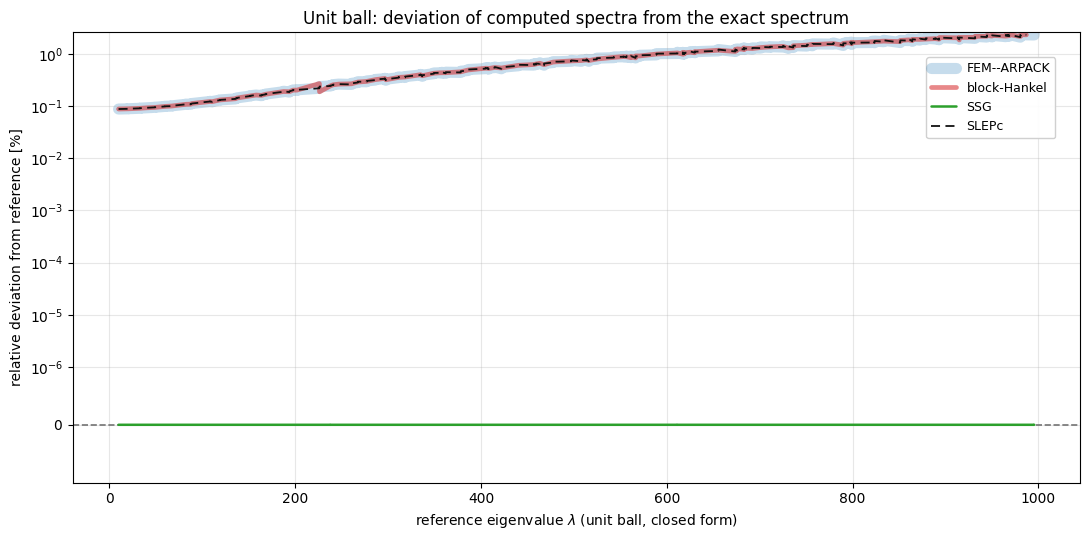

In [7]:
STYLES = {
    "FEM--ARPACK":  dict(color="#1f77b4", linestyle="-", linewidth=8.0, alpha=0.25, zorder=1),
    "block-Hankel": dict(color="#d62728", linestyle="-", linewidth=3.4, alpha=0.55, zorder=2),
    "SSG":          dict(color="#2ca02c", linestyle="-", linewidth=1.8, zorder=3),
    "SLEPc":        dict(color="#111111", linestyle=(0, (5, 3)), linewidth=1.3, zorder=4),
}
PLOT_ORDER = ["FEM--ARPACK", "block-Hankel", "SSG", "SLEPc"]

exact = exact_df["lambda_exact"].to_numpy()
LAM_MAX = min(exact[-1], *(v[-1] for v in spectra.values() if v is not None))
exact = exact[exact <= LAM_MAX]

fig, ax = plt.subplots(figsize=(11, 5.5))
for method in PLOT_ORDER:
    v = spectra.get(method)
    if v is None:
        continue
    n = min(len(v), len(exact))
    rel = (v[:n] - exact[:n]) / exact[:n]
    ax.plot(exact[:n], 100 * rel, label=method, solid_capstyle="round", **STYLES[method])

ax.axhline(0.0, color="0.45", linestyle="--", linewidth=1.2)
ax.set_yscale("symlog", linthresh=1e-6)
ax.set_ylim(bottom=-1e-6)
ax.set_ylabel("relative deviation from ground truth [%] (symlog)")
ax.set_xlabel(r"reference eigenvalue $\lambda$ (unit ball, closed form)")
ax.set_ylabel("relative deviation from reference [%]")
ax.set_title("Unit ball: deviation of computed spectra from the exact spectrum")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, framealpha=0.92, loc="upper right", borderaxespad=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "unitball_relative_deviation.png", dpi=150)
fig.savefig(FIG_DIR / "unitball_relative_deviation.pdf", bbox_inches="tight")
plt.show()

In [8]:
v = spectra["SSG"]; n = min(len(v), len(exact))
rel = np.abs(v[:n] - exact[:n]) / exact[:n]
print(f"SSG: median {np.median(rel):.2e}, max {rel.max():.2e}")

SSG: median 1.65e-14, max 1.12e-12


## 7. Multiplicity-aware splitting diagnostics

In [9]:
def multiplicity_diagnostics(method, comparison):
    rows = []
    for level_id, group in comparison.groupby("level_id", sort=True):
        exact_value = float(group["lambda_exact"].iloc[0])
        num = group["lambda_numerical"].to_numpy()
        rows.append({
            "method": method,
            "level_id": int(level_id),
            "l": int(group["l"].iloc[0]),
            "radial_index": int(group["radial_index"].iloc[0]),
            "multiplicity_expected": int(group["multiplicity"].iloc[0]),
            "multiplicity_observed_in_prefix": len(group),
            "lambda_exact": exact_value,
            "lambda_numerical_mean": float(np.mean(num)),
            "relative_center_error": float(abs(np.mean(num)-exact_value)/exact_value),
            "absolute_split_width": float(np.max(num)-np.min(num)),
            "relative_split_width": float((np.max(num)-np.min(num))/exact_value),
        })
    return pd.DataFrame(rows)

multiplicity_results = {
    method: multiplicity_diagnostics(method, df)
    for method, df in ordered_results.items()
}

for method, df in multiplicity_results.items():
    safe = method.lower().replace("-","_").replace(" ","_")
    df.to_csv(ANALYSIS_DIR / f"{safe}_multiplicity_diagnostics.csv", index=False)

display(pd.concat(multiplicity_results.values(), ignore_index=True).head(30))

,method,level_id,l,radial_index,multiplicity_expected,multiplicity_observed_in_prefix,lambda_exact,lambda_numerical_mean,relative_center_error,absolute_split_width,relative_split_width
0,FEM--ARPACK,0,0,1,1,1,9.869604,9.878297,0.000881,0.000000,0.000000
1,FEM--ARPACK,1,1,1,3,3,20.190729,20.208699,0.000890,0.000112,0.000006
2,FEM--ARPACK,2,2,1,5,5,33.217462,33.247690,0.000910,0.000347,0.000010
3,FEM--ARPACK,3,0,2,1,1,39.478418,39.515044,0.000928,0.000000,0.000000
4,FEM--ARPACK,4,3,1,7,7,48.831194,48.877403,0.000946,0.000601,0.000012
5,FEM--ARPACK,5,1,2,3,3,59.679516,59.738586,0.000990,0.000336,0.000006
6,FEM--ARPACK,6,4,1,9,9,66.954312,67.021597,0.001005,0.001070,0.000016
7,FEM--ARPACK,7,2,2,5,5,82.719231,82.809161,0.001087,0.000999,0.000012
8,FEM--ARPACK,8,5,1,11,11,87.531220,87.626877,0.001093,0.001725,0.000020
9,FEM--ARPACK,9,0,3,1,1,88.826440,88.926346,0.001125,0.000000,0.000000


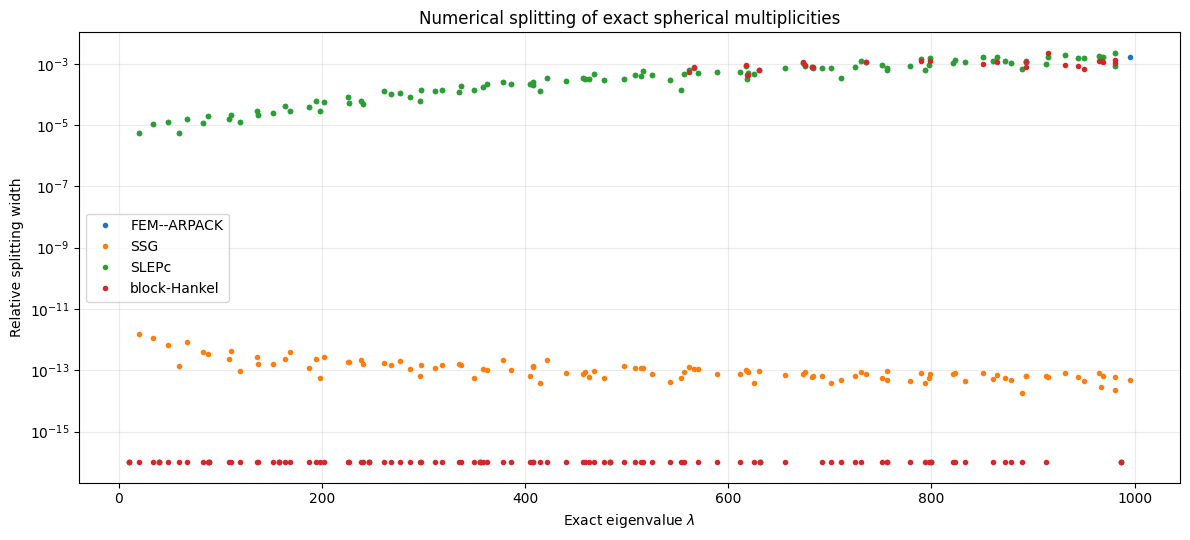

In [10]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for method, df in multiplicity_results.items():
    complete = df["multiplicity_observed_in_prefix"] == df["multiplicity_expected"]
    part = df[complete]
    ax.semilogy(part["lambda_exact"], np.maximum(part["relative_split_width"], 1e-16),
                marker=".", linestyle="none", label=method)
ax.set_xlabel(r"Exact eigenvalue $\lambda$")
ax.set_ylabel("Relative splitting width")
ax.set_title("Numerical splitting of exact spherical multiplicities")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "unit_ball_multiplicity_splitting.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "unit_ball_multiplicity_splitting.png", dpi=300, bbox_inches="tight")
plt.show()